**Disclaimer:** The following blocks of code have been developed specifically for accomplishing the goals set out for IAstro 2023's project Light My MOSFIRE. Using them for other purposes will require modification.

**The said goal**: Inspecting how the behaviour of galaxies on the Star Forming Main Sequence (SFMS) modifies depending on the section of SFMS under cosideration.

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM 
from astroML.datasets import fetch_sdss_spectrum
import pathlib

# Preliminary Things 

Combining relevant data from all files (FADO_SDSS.fits, FADO_Emission.fits, FADO_Params.fits, and FADO_Conversion.fits) into one comprehensive fits file, i.e., FADO_ALL.fits

In [ ]:
#Opening and reading the .fits files
sdss = fits.open(r"Fits_Files/Provided/FADO_SDSS.fits")  
sdss_data = sdss[1].data
sdss.close()

em = fits.open(r"Fits_Files/Provided/FADO_Emission.fits")
em_data = em[1].data
em.close()

parm = fits.open(r"Fits_Files/Provided/SDSS_Params.fits")
parm_data= parm[1].data
parm.close()

conv = fits.open(r"Fits_Files/Provided/FADO_Conversion.fits")
conv_data = conv[1].data
conv.close()

#Star Formation Rate (SFR) and Stellar Mass (SM) corrections are only available for 916118 galaxies in SDSS_Conversion.fits
#Selecting only those 916118 galaxies' indexes from the sdss,em, and params data
idxs = conv_data['INDEX']
sdss_data = sdss_data[idxs]
em_data = em_data[idxs]
parm_data = parm_data[idxs]

#Creating new table in which required data from other files will be added
fado_new = Table(sdss_data)

#from emissions file
fado_new['FOIII'] = em_data['Fobst_5007']  
fado_new['FNII'] = em_data['Fobst_6584']

#from params file
fado_new['ra'] = parm_data['ra']
fado_new['dec'] = parm_data['dec']
fado_new['z'] = parm_data['z']

#from conversion file
fado_new['SFR_Conv'] = conv_data['SFR_Conversion']
fado_new['LSM_Conv'] = conv_data['STELMASS_Conversion']

#Saving the new .fits file (location maybe changed)
fado_new_table = fits.BinTableHDU(fado_new)
fado_new_table.writeto(r"Fits_Files/FADO_ALL.fits", overwrite=True)

# Task 01: Initial Filtering

Select galaxies with S/N > 3 for the Hα and Hβ emission lines, as well as with stellar mass above $10^5$ solar mass.

This way we will (a) remove dwarf galaxies (low mass) and, (b) get rid of unreliable fluxes that have too much noise.

In [ ]:
#Opening the .fits file
fado = fits.open(r"Fits_Files/FADO_ALL.fits")  
fado_data = fado[1].data
fado.close()

#Extracting the necessary data from the .fits file
flux_Ha = fado_data['FObst_Ha'] 
fluxdev_Ha = fado_data['FOdev_Ha']

flux_Hb = fado_data['FObst_Hb']
fluxdev_Hb = fado_data['FOdev_Hb']

logM = fado_data['logMCbst']

#Calculating S/N ratio
sn_Ha = flux_Ha / fluxdev_Ha
sn_Hb = flux_Hb / fluxdev_Hb

#Adding the S/N ratio for Ha and Hb as new coloumns to previous data
snr_data = Table(fado_data)
snr_data['sn_Ha'] = sn_Ha  
snr_data['sn_Hb'] = sn_Hb

#Filtering galaxies based on S/N ratio and Stellar Mass
filtered_data = snr_data[(snr_data['logMCbst'] > 5) & (snr_data['sn_Ha'] > 3) & (snr_data['sn_Hb'] > 3)]

#Creating a new .fits table with the selected rows
filtered_table = fits.BinTableHDU(filtered_data)
all_snr_table = fits.BinTableHDU(snr_data) #all data with s/n ration

#Saving the new .fits table as a file
filtered_table.writeto(r"Fits_Files/selected_galaxies.fits", overwrite=True)
all_snr_table.writeto(r"Fits_Files/FADO_ALL_SNR.fits", overwrite=True)

# Task 02: Plotting BPT Diagram 

With the help of BPT diagram alongwith Kewley and Kauffman lines, we can separate galaxies into Star Forming (SF), Composite, and Active Galactic Nuclie (AGN). The SF galaxies lie below Kauffmann line, AGN above Kewely line, and Composite in between.

In [4]:
#Defining Kewley and Kauffmann fuctions for separation criteria and line!

def kauffmann(x):
    return (0.61/(x - 0.05)) + 1.3

def kewley(x):
    return (0.61/(x - 0.47)) + 1.19

In [ ]:
# Reading the .fits files with emission line data
sgal = fits.open(r"Fits_Files/selected_galaxies.fits")  
sgal_data = sgal[1].data
sgal.close()

ha = sgal_data['FObst_Ha']
hb = sgal_data['FObst_Hb']
nii = sgal_data['FNII']
oiii = sgal_data['FOIII']

#Calculating logarithms of the line ratios
log_nii_ha = np.log10(nii / ha) #x-axis
log_oiii_hb = np.log10(oiii / hb) #y-axis

#Adding new columns to galaxies, will need it later for classification
flux_ratio_data = Table(sgal_data)
flux_ratio_data['logrNHa'] = log_nii_ha  
flux_ratio_data['logrOHb'] = log_oiii_hb
    
#Separating galaxies for creating files
sf_data = flux_ratio_data[(flux_ratio_data['logrOHb'] < kauffmann(log_nii_ha))& (flux_ratio_data['logrNHa'] < 0.05)]
agn_data = flux_ratio_data[(flux_ratio_data['logrOHb'] > kewley(log_nii_ha))]
composite_data = flux_ratio_data[(flux_ratio_data['logrOHb'] >= kauffmann(log_nii_ha)) & (flux_ratio_data['logrOHb'] <= kewley(log_nii_ha))] 

#Creating and saving new .fits files for the three categories of galaxies.
sf_galaxies = fits.BinTableHDU(sf_data)
agn_galaxies = fits.BinTableHDU(agn_data)
composite_galaxies = fits.BinTableHDU(composite_data)

#Saving new files
sf_galaxies.writeto(r"Fits_Files/sf_galaxies.fits", overwrite=True)
agn_galaxies.writeto(r"Fits_Files/agn_galaxies.fits", overwrite=True)
composite_galaxies.writeto(r"Fits_Files/composite_galaxies.fits", overwrite=True)

C:\Users\marya\AppData\Local\Temp\ipykernel_12704\1005051752.py:12: RuntimeWarning: invalid value encountered in log10
  log_nii_ha = np.log10(nii / ha) #x-axis
C:\Users\marya\AppData\Local\Temp\ipykernel_12704\1005051752.py:13: RuntimeWarning: invalid value encountered in log10
  log_oiii_hb = np.log10(oiii / hb) #y-axis


### Creating the BPT Plot

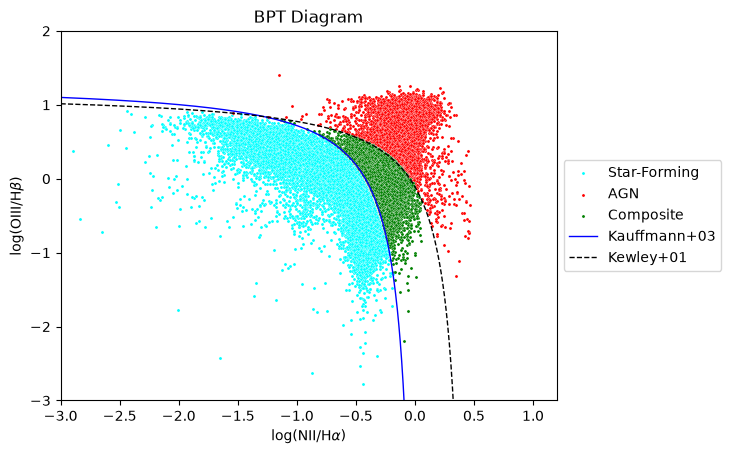

In [ ]:
# Reading and openeing the three .fits files 
sf = fits.open(r"Fits_Files/sf_galaxies.fits") 
sf_data = sf[1].data
sf.close()

agn = fits.open(r"Fits_Files/agn_galaxies.fits") 
agn_data = agn[1].data
agn.close()

composite = fits.open(r"Fits_Files/composite_galaxies.fits")
composite_data = composite[1].data
composite.close()

#Defining range of x-axis for Kauffman and Kewley line
#We are interested in the part right before the hyperbole nature becomes apparent
x_kauf = np.linspace(-3,0.04,1000)
x_kew = np.linspace(-3,0.4,1000)

#Create scatter plots using Seaborn (I could have used matplot but...hehehe)
sns.scatterplot(x=sf_data['logrNHa'], y=sf_data['logrOHb'],s=5, marker='o', color='cyan', label='Star-Forming')
sns.scatterplot(x=agn_data['logrNHa'], y=agn_data['logrOHb'],s=5, marker='o', color='red', label='AGN')
sns.scatterplot(x=composite_data['logrNHa'], y=composite_data['logrOHb'],s=5, marker='o', color='green', label='Composite')

sns.lineplot(x=x_kauf, y=kauffmann(x_kauf), linewidth=1, linestyle='-', color='blue', label='Kauffmann+03')
sns.lineplot(x=x_kew, y=kewley(x_kew), linewidth=1, linestyle='--', color='black', label='Kewley+01')

#Seaborn does not have inbuilt labelling and axis functionality, so we need matlibplot.pyplot for that
#Defining the maximum and minimum limit axis
Xmin, Xmax         = -3, 1.2  
Ymin, Ymax         = -3,2
plt.xlim(Xmin, Xmax)
plt.ylim(Ymin, Ymax)

#Adding labels and title
plt.xlabel(r'log(NII/H$\alpha$)')
plt.ylabel(r'log(OIII/H$\beta$)')
plt.title('BPT Diagram')

#Displaying the legend
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

#Saving the plot
plt.savefig(r"Graphs/BPT_Diagram.png", dpi=150, bbox_inches='tight', pad_inches=0.5)
plt.show()

# Task 03: Plotting the $\rm SFR_{fib}$ and $\rm SFR_{tot}$

Steps
1. Convert the redshift (from .fits file) to luminoisty distance in units of cm
2. Correct the $H\alpha$ flux (from .fits file). It should be units of $ \rm {erg/(s.cm^2)}$
3. Calcuate the Luminosity of $H \alpha$, i.e.  $L_{\alpha}$, in units of $\rm {erg/s}$
4. Get SFR by dividing $L_{\alpha}$ by $\eta$
5. Plot $log(\rm SFR_{fib}[\rm M_{\odot} \rm yr^{-1}])$ vs.$ log(r\ mM_*[\rm M_\odot])$, i.e. the fiber SFMS.
6. Apply the conditions (a) $log(F_{H\alpha})>-15.5 $  to remove SFMS outliers and (b) SFR and SM conversions from fiber (3 arcseconds) to total are between 0.01 and 10.
7. Apply the conversions (note: they are in in log, so add them instead of multiplying)
8. Plot the $log(\rm SFR_{tot}[\rm M_{\odot} \rm yr^{-1}])$ vs. $log(\rm M_{tot}[\rm M_\odot])$, i.e. the total SFMS.

### The next few block implements points 1-5

In [ ]:
# path_read = path to file with data for star-forming galaxies
# dir_out = path to directory where you want to save updated .fits
# name = name for the file

from zipfile import Path

def fibre_sfms(path_read,dir_out,name):    
    
    #Step 01: Reading and extracting data for forming galaxies
    
    sf = fits.open(path_read) 
    sf_data = sf[1].data
    sf.close()

    h_alp = sf_data['FObst_Ha']
    h_bet = sf_data['FObst_Hb']
    galsnorm = sf_data['galsnorm']
    redshift = sf_data['z'] #Mpsc
    log_m = sf_data['logMCbst']
    
    #Step 02: Caculating luminosity distnce from redshift
    
    #This considers the standard cosmology of a Flat Lambda CDM Universe
    from astropy.cosmology import FlatLambdaCDM 

    #This gives us the properties of the cosmology: Hubble constant of 70 km/(s Mpc) and Omega_matter = 0.3
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3) 

    #Converts redshift into luminosity distance according to your cosmology. 
    #This gives the distance in Mpc!
    lum_d_mpc = cosmo.luminosity_distance(redshift).to_value() 
    lum_d = lum_d_mpc*3.08567758e24

    print("Number of star-forming galaxies is:"+str(len(lum_d)))
    
    #Step 03: Correcting components of H-alpha flux for effects from dust in line of sight

    #Function for Charlot and Fall Extinction Law (2000)
    def k(n):
        return (n/5500)**(-0.7)

    #Colour Excess Correction Factor
    E = (2.5/(k(4861)-k(6563)))*np.log10((h_alp/h_bet)/2.86)

    #Attenuation
    A=E*k(6563)

    #Normalising Ha,by xing with galsnorm, and changing units from nanomaggies to erg/(scm^2) by xing with 1e17
    #Did not do this earlier, as previous step was Ha/Hb, so normalisation cancelled out
    h_alp_n = h_alp*galsnorm*1e-17

    #Getting corrected Ha flux
    ha_correct = h_alp_n*(10**(0.4*A))
    
    #Step 04: Calculating Luminosity of H-alpha and getting SFR
    
    #Ha luminosity calculation. Units of Luminosity are erg/s
    l_ha = ha_correct*4*np.pi*np.square(lum_d)

    #Converting Luminosity to solar mass per year to get SFR
    eta = 10**(41.31)
    LSFR = np.log10(l_ha/eta)
    
    #Step 05: Creating and saving new .fits file
    
    #Adding luminosity distance, corrected Ha, luminosity of Ha, and Log(SFR) as new columns
    ndata = Table(sf_data)
    ndata['LD_Mpc'] = lum_d_mpc
    ndata['LD_cm'] = lum_d  
    ndata['Ha_cor'] = ha_correct
    ndata['L_Ha'] = l_ha
    ndata['LSFR'] = LSFR

    #Saving .fits file
    
    output_dir = pathlib.Path(dir_out)
    output_dir.mkdir(parents=True, exist_ok=True)
    ndata = fits.BinTableHDU(ndata)
    ndata.writeto(output_dir / f"{name}.fits", overwrite=True)
     
    #Step 06: Plotting the fibre SFMS
    
    #Calculating 2D histogram
    counts, xedges, yedges = np.histogram2d(log_m,LSFR,bins=200)
    #Creating grid
    X, Y = np.meshgrid(xedges, yedges)
    #Plotting the SFMS
    contour = plt.contourf(X[:-1, :-1],Y[:-1, :-1], np.log10(counts).T,levels=4, cmap='viridis')
    plt.colorbar(contour,label='log(Counts)')

    #Defining SFMS baselines lines
    lm=np.linspace(5,12.5,1000)
    logsfr_u = 0.77*lm - 6.7
    logsfr = 0.77*lm - 7.43
    logsfr_l = 0.77*lm - 8.2 

    #Plotting baselines
    plt.plot(lm,logsfr_u, color='yellow', linestyle='--', linewidth = 1, label= r"log(SFR) = 0.77*log($M_\odot$) - 6.77")
    plt.plot(lm,logsfr, color='orange', linewidth = 1, label =r"log(SFR) = 0.77*log(M$_\odot$) - 7.43")
    plt.plot(lm,logsfr_l, color='red', linestyle='--', linewidth = 1, label= r"log(SFR) = 0.77*log(M$_\odot$) - 8.2")

    # Adding labels, title, and other plotting stuff
    plt.xlabel(r"log(M$_{*}$$_{fib}$[M$_{\odot}$])")
    plt.ylabel(r"log(SFR$_{fib}$[M$_{\odot}$ $yr^{-1}$])")
    plt.title('Star Forming Main Sequence (fiber)', pad=10)

    plt.xlim(5, 12)
    plt.ylim(-8, 4)
    plt.legend(loc='lower left')

    #Save the plot
    plt.savefig(r"Graphs\SFMS_fib.png", dpi=150, bbox_inches='tight', pad_inches=0.5)
    plt.show()

Number of star-forming galaxies is:202718


C:\Users\marya\AppData\Local\Temp\ipykernel_12704\3618847202.py:88: RuntimeWarning: divide by zero encountered in log10
  contour = plt.contourf(X[:-1, :-1],Y[:-1, :-1], np.log10(counts).T,levels=4, cmap='viridis')


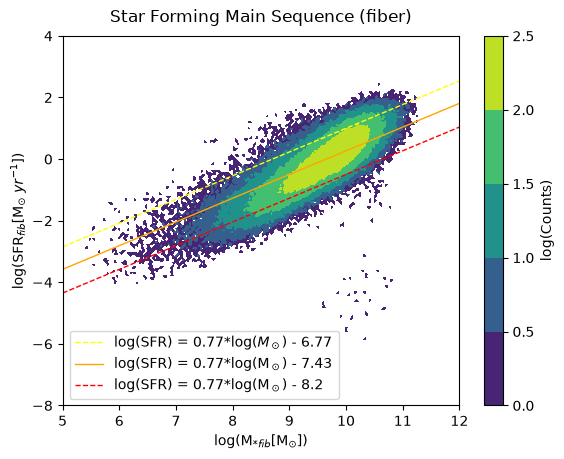

In [ ]:
path_read = r"Fits_Files\sf_galaxies.fits"
dir_out = r"Fits_Files"
name = "sf_galaxies_wsfr"
fibre_sfms(path_read,dir_out,name)

Applying the conditions (a) $log(F_{𝐻𝛼})>-15.5$ to remove SFMS outliers and (b) SFR conversion and SM conversion are between $0.01$ and $10$ and, the conversions (note: in log, so add them instead of multiplying)

In [ ]:
#Reading the file contating data about Corrected Ha, logSFR, and required logSm and logSFR correction factors
sfrgal = fits.open(r"Fits_Files\sf_galaxies_wsfr.fits") 
sfrgal_data = sfrgal[1].data
sfrgal.close()

#Short listing data based on corrected flux of H-alpha,0.01 < logSM and logSFR correction < 10
all_data = Table(sfrgal_data)
shortlisted = all_data[(np.log10(all_data['Ha_cor'])>-15.5) & (0.01 < all_data['SFR_Conv']) & (0.01 < all_data['LSM_Conv'])]
shortlisted = shortlisted[(shortlisted['LSM_Conv'] < 10)]

print("Number of shorlisted MSFM galaxies is", len(shortlisted['LSM_Conv']))

#Now that the data has been shortlisted, let's convert!
#Since all values are in log, we will add them.
lsfr_cor = shortlisted['LSFR'] + shortlisted['SFR_Conv']
lsm_cor=shortlisted['logMCbst'] + shortlisted['LSM_Conv']

#Save all this in a new file...ugh
shortlisted['LSFR_Cor'] = lsfr_cor
shortlisted['LSM_Cor'] = lsm_cor

short_data = fits.BinTableHDU(shortlisted)
short_data.writeto(r"Fits_Files\short_cor_sf_galaxies.fits", overwrite=True)

Number of shorlisted MSFM galaxies is 181498


Finally! Plotting the Total SFMS alongwith the division lines.

C:\Users\marya\AppData\Local\Temp\ipykernel_12704\1301138812.py:17: RuntimeWarning: divide by zero encountered in log10
  contour = plt.contourf(X[:-1, :-1],Y[:-1, :-1], np.log10(counts).T,levels=4, cmap='viridis')


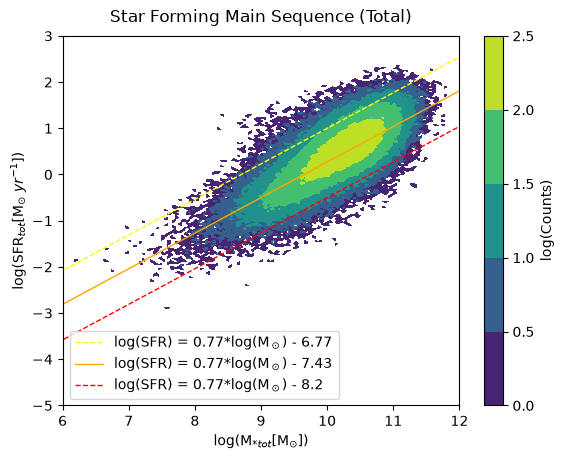

In [ ]:
#SFMS division lines
lm=np.linspace(5,12.5,1000)
logsfr_u = 0.77*lm - 6.7
logsfr = 0.77*lm - 7.43
logsfr_l = 0.77*lm - 8.2 

#Plotting baseline
plt.plot(lm,logsfr_u, color='yellow', linestyle='--', linewidth = 1, label=r"log(SFR) = 0.77*log(M$_\odot$) - 6.77")
plt.plot(lm,logsfr, color='orange', linewidth = 1, label =r"log(SFR) = 0.77*log(M$_\odot$) - 7.43")
plt.plot(lm,logsfr_l, color='red', linestyle='--', linewidth = 1, label=r"log(SFR) = 0.77*log(M$_\odot$) - 8.2")

#Calculate 2D histogram
counts, xedges, yedges = np.histogram2d(lsm_cor,lsfr_cor,bins=200)
#Create grid
X, Y = np.meshgrid(xedges, yedges)
#Plotting the SFMS
contour = plt.contourf(X[:-1, :-1],Y[:-1, :-1], np.log10(counts).T,levels=4, cmap='viridis')
plt.colorbar(contour,label='log(Counts)')

#Add labels and title
plt.xlabel(r'log(M$_{*}$$_{tot}$[M$_{\odot}$])')
plt.ylabel(r'log(SFR$_{tot}$[M$_{\odot}$ $yr^{-1}$])')
plt.title('Star Forming Main Sequence (Total)', pad=10)

plt.xlim(6, 12)
plt.ylim(-5, 3)

plt.legend(loc='lower left')

#Saving the plot ;-;
plt.savefig(r"Graphs\SFMS_total.png", dpi=150, bbox_inches='tight', pad_inches=0.5)
plt.show()

Same plot as above but with vertical lines.

C:\Users\marya\AppData\Local\Temp\ipykernel_12704\4265930495.py:3: RuntimeWarning: divide by zero encountered in log10
  contour = plt.contourf(X[:-1, :-1],Y[:-1, :-1], np.log10(counts).T,levels=4, cmap='viridis')


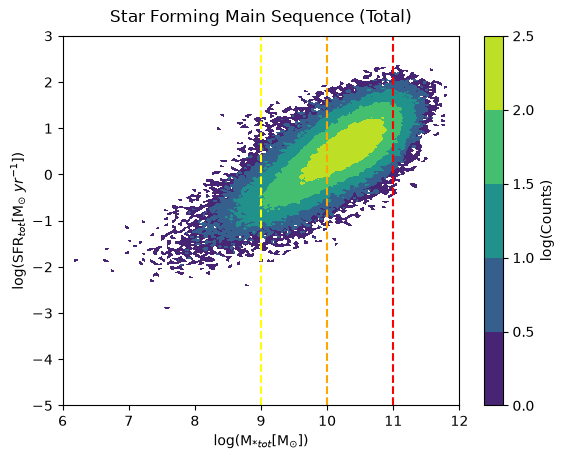

In [ ]:
counts, xedges, yedges = np.histogram2d(lsm_cor,lsfr_cor,bins=200)
X, Y = np.meshgrid(xedges, yedges)
contour = plt.contourf(X[:-1, :-1],Y[:-1, :-1], np.log10(counts).T,levels=4, cmap='viridis')
plt.colorbar(contour,label='log(Counts)')

#Adding vertical 'division' lines
plt.axvline(x=9, color='yellow', linestyle='--')
plt.axvline(x=10, color='orange', linestyle='--')
plt.axvline(x=11, color='red', linestyle='--')

plt.xlabel(r'log(M$_{*}$$_{tot}$[M$_{\odot}$])')
plt.ylabel(r'log(SFR$_{tot}$[M$_{\odot}$ $yr^{-1}$])')
plt.title('Star Forming Main Sequence (Total)', pad=10)

plt.xlim(6, 12)
plt.ylim(-5, 3)

plt.savefig(r"Graphs\SFMS_total_ver.png", dpi=150, bbox_inches='tight', pad_inches=0.5)
plt.show()

# Task 04: Creating a Sample of 50 Random Galaxies for one section of SFR and Stellar Mass

In the following block, I will create two samples of 50 galaxies and create two files for each.
1. One with plate, mjd, fiber, LSFR_Cor, Conv_SFR, and Conv_SM data
2. One wih RA and Dec in IPAC format

In [33]:
def section(sec,path_read,path_save,num_gal):
    #Reading the file contating data about Corrected Ha, logSFR, and required logSM and logSFR correction factors
    sel_sf_gal = fits.open(path_read) 
    sel_sf_gal_data = sel_sf_gal[1].data
    sel_sf_gal.close()

    all_sf_gal = Table(sel_sf_gal_data)

    # Selecting galaxies in the range (i) SFR >= upper boundary and (ii) log(SM) <= 9
    if sec == 1:
        sel_gal = all_sf_gal[(all_sf_gal['LSFR_Cor'] >= (0.77*all_sf_gal['LSM_Cor']-6.7))]
    elif sec == 2:
        sel_gal = all_sf_gal[(all_sf_gal['LSFR_Cor'] < (0.77*all_sf_gal['LSM_Cor']-6.7)) & (all_sf_gal['LSFR_Cor'] > (0.77*all_sf_gal['LSM_Cor']-7.43)) ]
    elif sec == 3:
        sel_gal = all_sf_gal[(all_sf_gal['LSFR_Cor'] < (0.77*all_sf_gal['LSM_Cor']-7.43)) & (all_sf_gal['LSFR_Cor'] > (0.77*all_sf_gal['LSM_Cor']-8.2)) ]
    elif sec == 4:
        sel_gal = all_sf_gal[(all_sf_gal['LSFR_Cor'] <= (0.77*all_sf_gal['LSM_Cor']-8.2))]
    elif sec == 5:
        sel_gal = all_sf_gal[(all_sf_gal['LSM_Cor'] <= 9)]
    elif sec == 6:
        sel_gal = all_sf_gal[(all_sf_gal['LSM_Cor'] > 9) & (all_sf_gal['LSM_Cor'] < 10)]
    elif sec == 7:
        sel_gal = all_sf_gal[(all_sf_gal['LSM_Cor'] > 10) & (all_sf_gal['LSM_Cor'] < 11)]
    elif sec == 8:
        sel_gal = all_sf_gal[(all_sf_gal['LSM_Cor'] >= 11)]
     
    # Randomly sampling num_gal galaxies from selected galaxies
    len_ran = len(sel_gal)
    sel_ind = [random.randint(0, len_ran) for _ in range(num_gal)]
    samp_gal = sel_gal[sel_ind]

    #Getting the plate,mjd,fiber, ra, and dec data
    plate,mjd,fib,ra,dec = samp_gal['plate'], samp_gal['mjd'],samp_gal['fiber'],samp_gal['ra'],samp_gal['dec']
    lsfr_cor = samp_gal['LSFR_Cor']
    #Creating .txt files
    np.savetxt(path_save+'\\samp_gal_data_%d_%d.txt' %(sec, num_gal), np.column_stack([plate,mjd,fib]), fmt='%d %d %d')
    np.savetxt(path_save+'\\sfr_%d_%d.txt' %(sec, num_gal), np.column_stack([lsfr_cor]), fmt='%f')

    #Create the Astropy Table and save it to a file in IPAC format (need this fromat to get clr excess correction from site mention 1 block down)
    Table([ra,dec], names=('ra', 'dec')).write(path_save+'\\samp_gal_radec_%d_%d.ipac' %(sec, num_gal), format='ascii.ipac', overwrite=True)


In [34]:
sec = 1
path_read = r"Fits_Files\short_cor_sf_galaxies.fits"
path_save = r"Txt_Files"
num_gal = 5 # opting for 5 galaxies rn for simplicity
section(sec,path_read,path_save,num_gal)

Using the IPAC files read the output (mean E-V) from  https://irsa.ipac.caltech.edu/applications/DUST/ to extract clr excess correction value and append it with plate mjd and fibre data.

It's best to copy the table, paste it in a .txt file, and then use the 4th column, or 4 in Python.

Note: You will need a new coloir excess correction file everytime you sample a new population.

In [28]:
# path_dust = file to .txt file with colour excess data
# path_pmf = path to file with plate,mjd,fiber,etc data
# name = name to be given to new file

def read_dust(path_dust,path_pmf,dir_out,name): #strings as input
    #Read .txt file with data from dust
    dust = np.loadtxt(path_dust, usecols=4, ndmin=1)

    # Read the existing data about pmf from .txt file
    pmf_data = pd.read_csv(path_pmf,header=None)

    if len(dust) != len(pmf_data):
        raise ValueError("The dust and PMF files have different numbers of rows.")
    
    # Add the new column to the DataFrame
    pmf_data['clr_exs'] = dust

    # Write the updated DataFrame back to the 'data.txt' file
    dir_out = pathlib.Path(dir_out)
    dir_out.mkdir(parents=True, exist_ok=True)
    output_path = dir_out / f"{name}.txt"

    pmf_data.to_csv(output_path, sep="\t", index=False, header=False)
    return output_path

In [30]:
path_dust = r"Txt_Files\samp_gal_1_5_clr.txt"
path_pmf = r"Txt_Files\samp_gal_data_1_5.txt"
dir_out = r"Txt_Files"
name = "samp_gal_data_1_5_clr"
read_dust(path_dust,path_pmf,dir_out,name)

WindowsPath('Txt_Files/samp_gal_data_1_5_clr.txt')

# Task 05: Creating the Input for FADO

Functions for, 
1. Foreground Correction 
2. Rest Frame Correction
3. Creating input file for FADO \
     (a) rest_spec_plate-mjd-fibre.txt with wavelength (Angstorm), flux, and flux error (both in erg/s cm) \
     (b) gal_list_runnumber.txt with the galaxy's filename (a) and luminosity distance (Mpc)  

In [31]:
# dir_txt = path to the directory where .txt files are to be saved
# dir_png = path to the directory where .png files are to be saved

def sdss_correct_txt(plate,mjd,fibre,clr_exs,dir_txt,dir_png):
  
    #Open spectrum
    spec = fetch_sdss_spectrum(plate,mjd,fibre)
    
    #name for .png and .txt files
    name = "%d-%d-%d" % (plate,mjd,fibre)
    
    #Define wavelengths, flux, flux error, and redshift
    wlngs = spec.wavelength() #converting from Angstrom to microns
    flux = spec.spectrum*1e-17
    flux_err = spec.error*1e-17
    z = spec.z
    
    #Calculating Luminosity distance in Mpc
    #This gives you the properties of the cosmology: Hubble constant of 70 km/(s Mpc) and Omega_matter = 0.3
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3) 
    #Converts redshift into luminosity distance according to your cosmology. 
    lum_d = cosmo.luminosity_distance(z).to_value() 
    
    #Foreground extinction correction
    #Calculate extinction law
    Rv = 3.1

    def ext(lamb,R):
        x = 1/(lamb*1e-4) #using wavelength in microns 
        y = x - 1.82
        a = 1 + (0.17699*y) - (0.50447*(y**2)) - (0.02427*(y**3)) + (0.72085*(y**4)) + (0.01979*(y**5)) - (0.77530*(y**6)) + (0.32999*(y**7))
        b = (1.41338*y) + (2.28305*(y**2)) + (1.07233*(y**3)) - (5.38434*(y**4)) - (0.62251*(y**5)) + (5.30260*(y**6)) - (2.09002*(y**7))
        return a+(b/R)
    
    #Apply the correction to flux correction
    flux_crc = flux*10**(0.4*clr_exs*Rv*ext(wlngs,Rv))
    flux_err_crc = flux_err*10**(0.4*clr_exs*Rv*ext(wlngs,Rv))
    
    #Conversion to reference restframe
    wlngs_r = wlngs/(1+z)
    flux_r = flux_crc*(1+z)
    flux_e_r = flux_err_crc*(1+z)
    
    #Plot the multiple spectraaaaaa
    plt.figure(figsize=(12, 6))
    plt.plot(wlngs,flux, color='blue',linewidth=1, label="Observed Spectrum")
    plt.plot(wlngs,flux_crc, color='orange', linewidth=1,label ="Extinction Corrected Spectrum")
    plt.plot(wlngs_r,flux_r, color='green',linewidth=1, label="Extinction + Restframe Corrected ")
    plt.ylim(0, 1e-15)
    
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel(r'Flux[erg s$^{-1}$ cm$^{-2}$ $\AA$$^{-1}$]')
    plt.title('SDSS %s (z=%f)' %(name,z), pad=10)
    plt.legend(loc='upper right')
    plt.savefig(dir_png / f"{name}.png", dpi=150, bbox_inches='tight', pad_inches=0.5)
    plt.close()
    
    #Saving the .txt file with corrected wavelength, flux, and flux uncertainity
    filename = 'rest_spec_%s.txt' %name
    np.savetxt(dir_txt / f"{filename}", np.column_stack([wlngs_r,flux_r,flux_e_r]), fmt='%.15e %.15e %.15e')

    return lum_d, filename 

#file_path = path to the .txt file 
#that contains plate, mjd, fibre, and clr_exs columns

#run_name = any short name for the run

def FADO_input(file_path,run_name,dir_txt,dir_png):

    # Read the file to get plate, mjd, fibre and clr_exs
    # Using numpy's loadtxt function to read the file directly into a NumPy array
    data_array = np.loadtxt(file_path)
     
    # Defining array for storing luminosity distance and filename for each galaxy
    lum_dist = []
    name_txt = []
    
    #Corrections are done galaxy by galaxy, in a loop
    for n in range(len(data_array)):
        plate,mjd,fibre,clr_exs = data_array[n,0], data_array[n,1], data_array[n,2], data_array[n,3]
        
        lumd,filename = sdss_correct_txt(plate,mjd,fibre,clr_exs,dir_txt,dir_png)
        lum_dist.append(lumd)
        name_txt.append(filename)
        
    # Writing and saving file with  galaxy filename and distance  
    with open(dir_txt / f"gal_list_{run_name}.txt",'w') as txt_file:
        for i in range(len(name_txt)):
            txt_file.write(name_txt[i]+' '+str(lum_dist[i])+"\n")

In [ ]:
# using a list of sample galaxies, that we used as baselien to verify our code.
# This file contains plate, mjd, fibre, and clr_exs columns for 5 galaxies.
# (not the same as the 5 galaxies we randomly selected earlier)

file_path = r"Txt_Files\sample_galaxy_input_prep.txt" 
dir_txt = pathlib.Path(r"FADO\input\sample")
dir_png = pathlib.Path(r"Graphs\sample")
run_name = "sample"

FADO_input(file_path,run_name,dir_txt,dir_png)

# Task 06:Processing FADO's Output

FADO's output can be manipulated in a number of ways, but for this project, we will extract specific properties (listed below) and then compare the median value from 50 galaxies from each region, with eachother.

The quantities are,

(from ST.fits)
- SFR
- Stellar Mass, SM weighted by Light, and SM weighted by Age
- Metallicity weighted by Light, and Metallicity weighted by Mass
- Number of ionising photons for H,HeI, and HeII
- Flux and Equivalent Width of $H\alpha$
- Flux and Equivalent Width of $H\beta$

(from EL.fits)
- Flux and Equivalent Width of OIII

(from 1D.fits)
- Nebular Contribution (Find the median of this fro each galalxy, further find the median for the 50 meidans)
    
Some interesting plots to look into,
1. Stellar Mass (or SFR) vs Age (light-weighted or mass weighted)
2. Stellar Mass (or SFR) vs Stellar Metallicity (both)
3. Stellar Mass (or SFR) vs Number of Ionising photons (all three of them)
4. Stellar Mass or SFR or Equivalent Width($H\alpha$) vs Nebular contribution
5. EW(Hbeta) vs the ratio of the fluxes of OIII and $H\beta$

In [39]:
#The following function reads _ST,and _1D files to extract relevant values for all galaxies for an input file
# tag_caps = the name of the folder in FADO/output where the _ST and _1D files are stored
# run_name = the name of the input file (gal_list_*.txt) in FADO/input
def getting_values(tag_caps,run_name):
    filelist = pd.read_csv(r"FADO\input\gal_list_%s.txt" %run_name, sep=' ', header=None, names=['name', 'distance'])
    sfr_list = np.loadtxt(r"Txt_Files\sfr_%s.txt" %run_name)
    
    #Creating lists to store values for each galaxy
    stellar_mass = []
    sm_wb_l = []
    sm_wb_age = []
    met_wb_l = []
    met_wb_m = []
    ion_H = []
    ion_HeI = []
    ion_HeII = []
    med_neb = []
    neb_cont = []
    f_Ha = []
    ew_Ha  = []
    f_Hb  = []
    ew_Hb  = []
    f_O = []
    ew_O = []

    # Loop through the data and perform operations
    for index, row in filelist.iterrows():
        name = row['name']
        lum_dist = row['distance']
        
        st = fits.open(r"FADO\output\%s\spectra\%s.FADO_ST.fits" %(tag_caps,name))
        st_data = st[0].data
        
        stellar_mass.append(st[0].header['logMCbst'])
        sm_wb_l.append(st[0].header['bst_Lage'])
        sm_wb_age.append(st[0].header['bst_Mage'])
        met_wb_l.append(st[0].header['bst_Lmet'])
        met_wb_m.append(st[0].header['bst_Mmet'])
        ion_H.append(st[0].header['bstlogQH'])
        ion_HeI.append(st[0].header['Blg_QHeI'])
        ion_HeII.append(st[0].header['BlgQHeII'])
        f_Ha.append(st[0].header['FObst_Ha'])
        f_Hb.append(st[0].header['FObst_Hb'])
        #ew_Ha.append(st[0].header['EObst_Ha'])
        #ew_Hb.append(st[0].header['EObst_Hb'])       
        
        #Finding the nebular contribution
        d = fits.open(r"FADO\output\%s\spectra\%s.FADO_1D.fits" %(tag_caps,name))
        spec_data = d[0].data
        tot_mod = spec_data[3]
        neb_mod = spec_data[8]
        neb_cont.append((np.median(neb_mod[tot_mod>0]/tot_mod[tot_mod>0]))*100)
        
    #Saving median values of everything
    variables = ['SFR','Stel. Mass', 'Stel. Mass wtd. by Age', 'Stel. Mass wtd. by Light',
                 'Stel. Metalicity wtd. by Light', 'Stel. Metalicity wtd. by Mass', 'No. Ionising Photons for H',
                 'No. Ionising Photons for HeI',  'No. Ionising Photons for HeII', 'Nebular Contribution']
    
    median_val = [np.median(sfr_list),np.median(stellar_mass), np.median(sm_wb_l),np.median(sm_wb_age),np.median(met_wb_l),np.median(met_wb_m),
                  np.median(ion_H),np.median(ion_HeI), np.median(ion_HeII), np.median(neb_cont)]
    
    with open(r"Processed_FADO_Output\edian_list_%s.txt" %tag_caps,'w') as txt_file:
        for i in range(len(median_val)):
            txt_file.write(variables[i]+' '+str(median_val[i])+"\n")
    
    #Saving data in CSV file for potential future plotting
    data = {'SFR': sfr_list,'SM': stellar_mass,'SMwA': sm_wb_age,'SMwL': sm_wb_l, 'MetwL': met_wb_l,'MetwM': met_wb_m,'nipH': ion_H, 'nipHeI':ion_HeI,
    'nipHeII':ion_HeII, 'Flux_Ha':f_Ha, 'Flux_Hb': f_Hb, 'Neb_Cont.':neb_cont}
    
    df = pd.DataFrame(data)
    df.to_csv(r"Processed_FADO_Output\ADO_output_%s.csv" %run_name, index=False, header=True)

In [ ]:
# the run_name/tag_caps sfr is for the samp_gal_data_1_50_clr run
# the run_name/tag_caps sm is for the samp_gal_data_5_50_clr run
tag_caps = "sfr"
run_name = "sfr"
getting_values(tag_caps,run_name)

## Extra Code Pieces

### Reading FADO's Output (1D.fits) and Plotting the Spectra

The following function's input is the path to FADO terminal's input file (with the list of .txt file names) for spectra processing. It uses it to read the 1D.fits output files and then creates a plot with 4 spectra (input,model,stellar,nebular).

In [6]:
#filepath = path to the .txt file that conatins list of spectra
#dir_1d = path to the directory where 1D.fits files are
#dir_png = path to the directory where pngs are to be saved

def FADO_1D_out_spect(filepath,dir_1d,dir_png):
    dir_1d = pathlib.Path(dir_1d)
    dir_png = pathlib.Path(dir_png)

    #Reading the .txt file
    data_array = np.loadtxt(filepath, dtype = str)
    
    #Reading, extracting, and plotting data from _1D.fits file happens in this loop
    #The loop runs for each galaxy
    for i in range(len(data_array)):
        name = data_array[i,0]
        f = fits.open(dir_1d/f"{name}.FADO_1D.fits")
        spec_data = f[0].data

        #The following 3 are all single values
        #Define the first wavelength of the array
        wlgs_0 = f[0].header['CRVAL1']
        #Define the step between wavelength values
        wlgs_delta = f[0].header['CDELT1']
        #Define the normalisation factor
        norm_flux = f[0].header['GALSNORM']

        #Define the wavelengths array
        wavelengths = wlgs_0+np.arange(0,len(spec_data[0]))*wlgs_delta
        #Define the fluxes of the input spectrum
        input_spec = spec_data[0]*norm_flux
        #Define the fluxes of the total model spectrum
        model_spec = spec_data[3]*norm_flux
        #Define the fluxes of the stellar model spectrum
        stellar_spec = spec_data[7]*norm_flux
        #Define the fluxes of the nebular model spectrum
        nebular_spec = spec_data[8]*norm_flux
        
        #splitting rest_spec_plate-mjd-fibre.txt to isolate plate-mjd-fibre for graph names
        galaxy_name = name.split('.')[0]
        galaxy_name = galaxy_name.split('_')[2]

        #Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(wavelengths,input_spec, color='darkblue',linewidth=1, label="Input")
        plt.plot(wavelengths,model_spec, color='aquamarine', linewidth=1,label ="Model")
        plt.plot(wavelengths,stellar_spec, color='orange',linewidth=1, label="Stellar")
        plt.plot(wavelengths,nebular_spec, color='gold',linewidth=1, label="Nebular")
        plt.ylim(0, 1e-15)
        plt.xlabel(r'Wavelength ($\AA$)')
        plt.ylabel(r'Flux[erg s$^{-1}$ cm$^{-2}$ $\AA$$^{-1}$]')
        plt.title('Spectra for %s' % galaxy_name, pad=10)
        plt.legend(loc='upper right')
        plt.savefig(dir_png/f"out_{galaxy_name}.png", dpi=150, bbox_inches='tight', pad_inches=0.5)
        plt.close()

In [7]:
# Running this for the 5 sample galaxies
filepath = r"FADO\input\sample\gal_list_sample.txt"
dir_1d = r"FADO\output\sample\spectra"
dir_png = r"FADO\output\sample\graphs"
FADO_1D_out_spect(filepath,dir_1d,dir_png)